In [1]:
from google.colab import files
uploaded = files.upload()

Saving 3mfanddo.csv to 3mfanddo.csv


In [2]:
# Cell 2 — Install & Load
import subprocess
subprocess.run(["pip", "install", "pandas", "numpy", "scikit-learn", "torch", "matplotlib", "plotly", "seaborn", "scipy"], capture_output=True)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import warnings
warnings.filterwarnings('ignore')

# Load data
df = pd.read_csv('3mfanddo.csv')
print(f"Shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
df.head()

Shape: (2533210, 16)
Columns: ['Unnamed: 0', 'INSTRUMENT', 'SYMBOL', 'EXPIRY_DT', 'STRIKE_PR', 'OPTION_TYP', 'OPEN', 'HIGH', 'LOW', 'CLOSE', 'SETTLE_PR', 'CONTRACTS', 'VAL_INLAKH', 'OPEN_INT', 'CHG_IN_OI', 'TIMESTAMP']


,Unnamed: 0,INSTRUMENT,SYMBOL,EXPIRY_DT,STRIKE_PR,OPTION_TYP,OPEN,HIGH,LOW,CLOSE,SETTLE_PR,CONTRACTS,VAL_INLAKH,OPEN_INT,CHG_IN_OI,TIMESTAMP
0,160393,FUTIDX,BANKNIFTY,29-Aug-2019,0.0,XX,28805.65,28924.00,28140.55,28499.30,28499.30,214569.0,1225914.96,1675780.0,234640.0,01-AUG-2019
1,160394,FUTIDX,BANKNIFTY,26-Sep-2019,0.0,XX,28926.40,29030.55,28251.70,28611.45,28611.45,2484.0,14245.95,51400.0,-80.0,01-AUG-2019
2,160395,FUTIDX,BANKNIFTY,31-Oct-2019,0.0,XX,29000.00,29105.00,28355.55,28699.05,28699.05,598.0,3434.43,9460.0,4860.0,01-AUG-2019
3,160396,FUTIDX,NIFTY,29-Aug-2019,0.0,XX,11098.40,11098.40,10901.10,11015.35,11015.35,199881.0,1650955.24,19001400.0,1339200.0,01-AUG-2019
4,160397,FUTIDX,NIFTY,26-Sep-2019,0.0,XX,11136.35,11145.20,10955.00,11066.60,11066.60,5283.0,43841.57,893625.0,66750.0,01-AUG-2019


In [3]:
# Cell 3 — Feature Engineering
df = df.drop(columns=["Unnamed: 0"])
df["TIMESTAMP"] = pd.to_datetime(df["TIMESTAMP"], format="%d-%b-%Y")
df["EXPIRY_DT"] = pd.to_datetime(df["EXPIRY_DT"], format="%d-%b-%Y")

# Work on options only (CE + PE)
options = df[df["OPTION_TYP"].isin(["CE", "PE"])].copy()
options = options.sort_values(["SYMBOL", "TIMESTAMP"])

print(f"Options rows: {len(options):,}")

# Feature 1: OI Change Rate
options["oi_change_rate"] = options["CHG_IN_OI"] / (options["OPEN_INT"] + 1)

# Feature 2: Volume Z-Score per symbol
options["contracts_zscore"] = options.groupby("SYMBOL")["CONTRACTS"].transform(
    lambda x: (x - x.mean()) / (x.std() + 1e-9)
)

# Feature 3: Rolling 7-day Volatility
options["price_range"] = options["HIGH"] - options["LOW"]
options["rolling_volatility"] = options.groupby("SYMBOL")["price_range"].transform(
    lambda x: x.rolling(7, min_periods=1).std()
)

# Feature 4: Put-Call Ratio
daily_pcr = options.groupby(["TIMESTAMP", "SYMBOL", "OPTION_TYP"])["OPEN_INT"].sum().unstack(fill_value=0)
if "PE" in daily_pcr.columns and "CE" in daily_pcr.columns:
    daily_pcr["pcr"] = daily_pcr["PE"] / (daily_pcr["CE"] + 1)
else:
    daily_pcr["pcr"] = 0
daily_pcr = daily_pcr[["pcr"]].reset_index()
options = options.merge(daily_pcr, on=["TIMESTAMP", "SYMBOL"], how="left")

# Feature 5: Days to expiry
options["days_to_expiry"] = (options["EXPIRY_DT"] - options["TIMESTAMP"]).dt.days
options["is_expiry_week"] = (options["days_to_expiry"] <= 7).astype(int)

# Feature 6: Value per contract
options["value_per_contract"] = options["VAL_INLAKH"] / (options["CONTRACTS"] + 1)

# Feature 7: OI Surge
options["oi_surge"] = options.groupby("SYMBOL")["CHG_IN_OI"].transform(
    lambda x: x / (x.rolling(7, min_periods=1).mean().abs() + 1)
)

feature_cols = [
    "oi_change_rate", "contracts_zscore", "rolling_volatility",
    "pcr", "is_expiry_week", "value_per_contract", "oi_surge"
]

options = options.dropna(subset=feature_cols)
print(f"After feature engineering: {len(options):,} rows")
print(f"\nFeature summary:")
options[feature_cols].describe()

Options rows: 2,501,238
After feature engineering: 2,501,074 rows

Feature summary:


,oi_change_rate,contracts_zscore,rolling_volatility,pcr,is_expiry_week,value_per_contract,oi_surge
count,2.501074e+06,2.501074e+06,2.501074e+06,2.501074e+06,2.501074e+06,2.501074e+06,2.501074e+06
mean,-4.733027e+00,1.067444e-05,2.442556e+00,8.146316e-01,9.910662e-02,8.820557e-01,1.282157e+00
std,5.875963e+02,9.999992e-01,1.695012e+01,3.306923e+00,2.988052e-01,2.186058e+00,8.619032e+02
min,-2.880000e+05,-2.728317e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,-2.240000e+05
25%,0.000000e+00,-1.878364e-01,0.000000e+00,4.886351e-01,0.000000e+00,0.000000e+00,0.000000e+00
50%,0.000000e+00,-1.472429e-01,0.000000e+00,6.326731e-01,0.000000e+00,0.000000e+00,0.000000e+00
75%,0.000000e+00,-8.467759e-02,3.933979e-02,8.944849e-01,0.000000e+00,0.000000e+00,0.000000e+00
max,9.999997e-01,1.907564e+02,1.330797e+03,1.750000e+02,1.000000e+00,1.642818e+01,3.825000e+05


In [4]:
# Cell 4 — Scale + Isolation Forest + DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN

# Scale features
print("Scaling features...")
scaler = StandardScaler()
X = scaler.fit_transform(options[feature_cols].fillna(0))
print(f"Feature matrix: {X.shape}")

# ── Isolation Forest ──────────────────────────────────────
print("\nTraining Isolation Forest (this takes ~1 min)...")
iso_forest = IsolationForest(
    n_estimators=200,
    contamination=0.05,
    random_state=42,
    n_jobs=-1
)
iso_forest.fit(X)
if_preds = (iso_forest.predict(X) == -1).astype(int)
print(f"Isolation Forest: {if_preds.sum():,} anomalies ({if_preds.mean()*100:.1f}%)")

# ── DBSCAN (on subsample) ─────────────────────────────────
print("\nRunning DBSCAN on 50k subsample...")
np.random.seed(42)
idx = np.random.choice(len(X), 50000, replace=False)
X_sample = X[idx]

dbscan = DBSCAN(eps=0.5, min_samples=10, n_jobs=-1)
labels = dbscan.fit_predict(X_sample)

dbscan_preds = np.zeros(len(X))
anomaly_idx = idx[labels == -1]
dbscan_preds[anomaly_idx] = 1

n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
print(f"DBSCAN: {n_clusters} clusters, {(labels==-1).sum():,} anomalies in sample ({(labels==-1).mean()*100:.1f}%)")

print("\nIsolation Forest + DBSCAN done!")

Scaling features...
Feature matrix: (2501074, 7)

Training Isolation Forest (this takes ~1 min)...
Isolation Forest: 125,054 anomalies (5.0%)

Running DBSCAN on 50k subsample...
DBSCAN: 4 clusters, 842 anomalies in sample (1.7%)

Isolation Forest + DBSCAN done!


In [5]:
# Cell 5 — LSTM Autoencoder
import torch
import torch.nn as nn

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

class LSTMAutoencoder(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, num_layers=2):
        super().__init__()
        self.encoder = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.decoder = nn.LSTM(hidden_dim, hidden_dim, num_layers, batch_first=True, dropout=0.2)
        self.output_layer = nn.Linear(hidden_dim, input_dim)

    def forward(self, x):
        _, (hidden, _) = self.encoder(x)
        decoder_input = hidden[-1].unsqueeze(1).repeat(1, x.size(1), 1)
        decoded, _ = self.decoder(decoder_input)
        return self.output_layer(decoded)

# Subsample 100k rows for training
np.random.seed(42)
idx_lstm = np.random.choice(len(X), 100000, replace=False)
X_sample = X[idx_lstm]

# Create sequences
SEQ_LEN = 10
sequences = np.array([X_sample[i:i+SEQ_LEN] for i in range(len(X_sample) - SEQ_LEN)])
tensor = torch.FloatTensor(sequences).to(device)

print(f"Training sequences: {tensor.shape}")

# Train
model = LSTMAutoencoder(input_dim=7).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

EPOCHS = 30
BATCH_SIZE = 512

model.train()
for epoch in range(EPOCHS):
    total_loss = 0
    for i in range(0, len(tensor), BATCH_SIZE):
        batch = tensor[i:i+BATCH_SIZE]
        optimizer.zero_grad()
        reconstructed = model(batch)
        loss = criterion(reconstructed, batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    if (epoch+1) % 5 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — Loss: {total_loss/len(tensor):.6f}")

# Compute threshold
model.eval()
with torch.no_grad():
    recon = model(tensor)
    errors = ((tensor - recon)**2).mean(dim=(1,2)).cpu().numpy()

threshold = np.percentile(errors, 95)
print(f"\nLSTM threshold: {threshold:.6f}")

# Predict on full dataset
all_sequences = np.array([X[i:i+SEQ_LEN] for i in range(len(X) - SEQ_LEN)])
all_tensor = torch.FloatTensor(all_sequences).to(device)

lstm_preds = np.zeros(len(X))
model.eval()
with torch.no_grad():
    for i in range(0, len(all_tensor), 1024):
        batch = all_tensor[i:i+1024]
        recon = model(batch)
        errs = ((batch - recon)**2).mean(dim=(1,2)).cpu().numpy()
        for j, err in enumerate(errs):
            if err > threshold:
                lstm_preds[i+j+SEQ_LEN-1] = 1

print(f"LSTM Autoencoder: {int(lstm_preds.sum()):,} anomalies ({lstm_preds.mean()*100:.1f}%)")
print("LSTM done!")

Using device: cuda
Training sequences: torch.Size([99990, 10, 7])
Epoch 5/30 — Loss: 0.001332
Epoch 10/30 — Loss: 0.001150
Epoch 15/30 — Loss: 0.001139
Epoch 20/30 — Loss: 0.000983
Epoch 25/30 — Loss: 0.000918
Epoch 30/30 — Loss: 0.000822

LSTM threshold: 0.270588
LSTM Autoencoder: 241,421 anomalies (9.7%)
LSTM done!


── Anomaly Detection Results ──
Isolation Forest:  125,054 anomalies (5.0%)
LSTM Autoencoder:  241,421 anomalies (9.7%)
DBSCAN:            842 anomalies (0.0%)
Ensemble:          78,404 anomalies (3.1%)


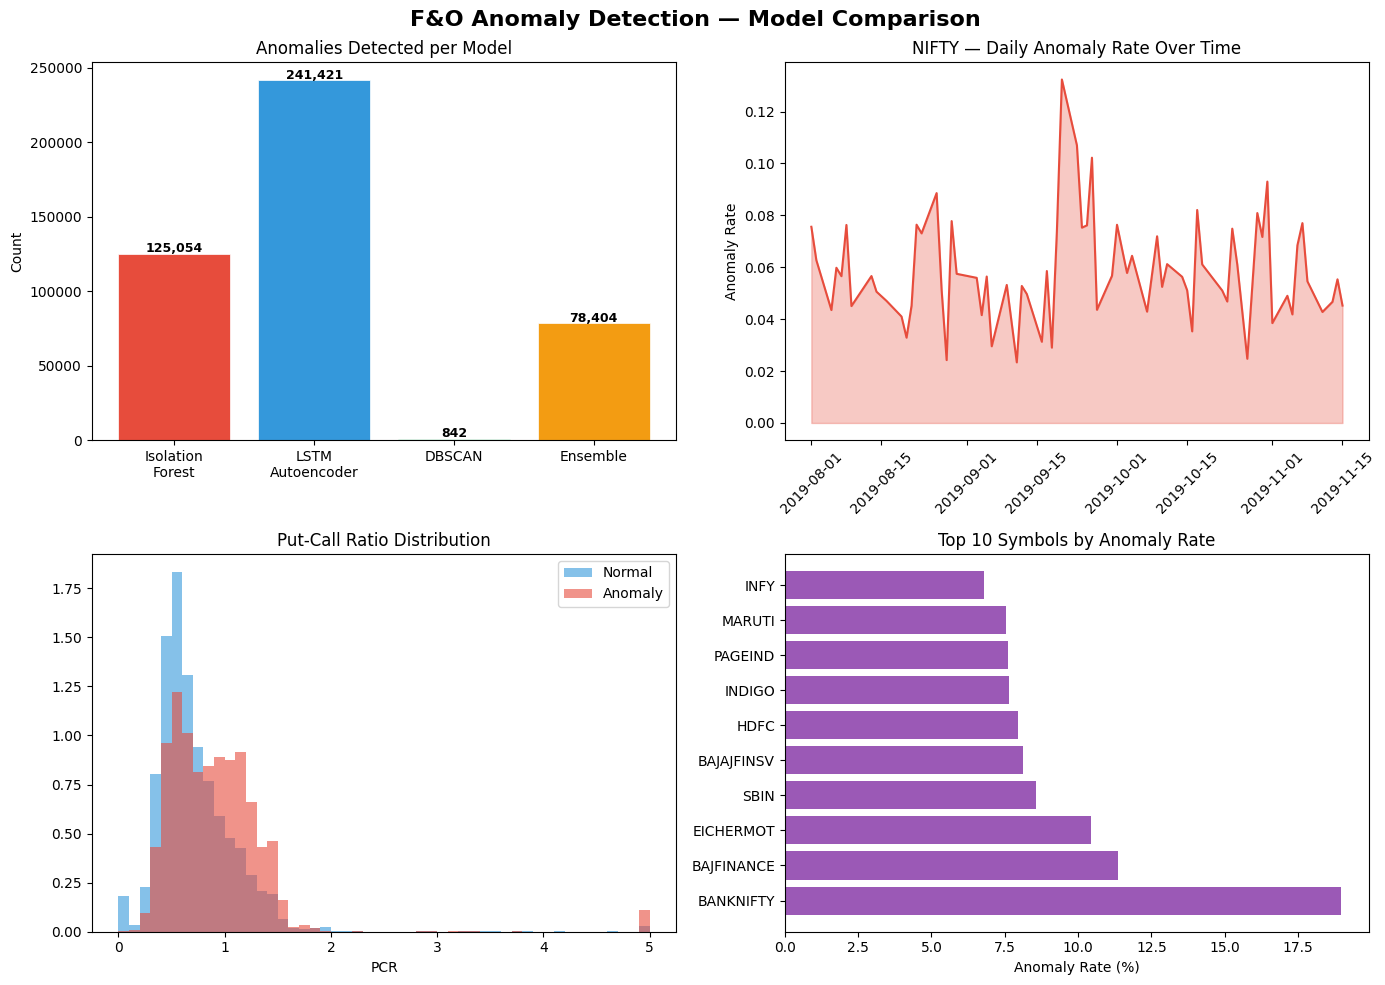

Plot saved!


In [6]:
# Cell 6 — Ensemble + Visualizations
import matplotlib.pyplot as plt
import seaborn as sns

# ── Ensemble ──────────────────────────────────────────────
ensemble_score = 0.4 * if_preds + 0.4 * lstm_preds + 0.2 * dbscan_preds
ensemble_preds = (ensemble_score >= 0.5).astype(int)

# Add to dataframe
options = options.reset_index(drop=True)
options["if_anomaly"] = if_preds
options["lstm_anomaly"] = lstm_preds
options["dbscan_anomaly"] = dbscan_preds
options["ensemble_score"] = ensemble_score
options["ensemble_anomaly"] = ensemble_preds

print("── Anomaly Detection Results ──")
print(f"Isolation Forest:  {if_preds.sum():,} anomalies ({if_preds.mean()*100:.1f}%)")
print(f"LSTM Autoencoder:  {int(lstm_preds.sum()):,} anomalies ({lstm_preds.mean()*100:.1f}%)")
print(f"DBSCAN:            {int(dbscan_preds.sum()):,} anomalies ({dbscan_preds.mean()*100:.1f}%)")
print(f"Ensemble:          {ensemble_preds.sum():,} anomalies ({ensemble_preds.mean()*100:.1f}%)")

# ── Plot 1: Model Comparison Bar Chart ───────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("F&O Anomaly Detection — Model Comparison", fontsize=16, fontweight='bold')

models = ['Isolation\nForest', 'LSTM\nAutoencoder', 'DBSCAN', 'Ensemble']
counts = [if_preds.sum(), int(lstm_preds.sum()), int(dbscan_preds.sum()), ensemble_preds.sum()]
colors = ['#e74c3c', '#3498db', '#2ecc71', '#f39c12']

axes[0,0].bar(models, counts, color=colors, edgecolor='white', linewidth=0.5)
axes[0,0].set_title("Anomalies Detected per Model")
axes[0,0].set_ylabel("Count")
for i, v in enumerate(counts):
    axes[0,0].text(i, v + 1000, f'{v:,}', ha='center', fontsize=9, fontweight='bold')

# ── Plot 2: Anomalies over Time (NIFTY) ──────────────────
nifty = options[options["SYMBOL"] == "NIFTY"].copy()
daily = nifty.groupby("TIMESTAMP").agg(
    total=("ensemble_anomaly", "count"),
    anomalies=("ensemble_anomaly", "sum")
).reset_index()
daily["anomaly_rate"] = daily["anomalies"] / daily["total"]

axes[0,1].plot(daily["TIMESTAMP"], daily["anomaly_rate"], color='#e74c3c', linewidth=1.5)
axes[0,1].fill_between(daily["TIMESTAMP"], daily["anomaly_rate"], alpha=0.3, color='#e74c3c')
axes[0,1].set_title("NIFTY — Daily Anomaly Rate Over Time")
axes[0,1].set_ylabel("Anomaly Rate")
axes[0,1].tick_params(axis='x', rotation=45)

# ── Plot 3: PCR Distribution — Normal vs Anomaly ─────────
normal_pcr = options[options["ensemble_anomaly"] == 0]["pcr"].clip(0, 5)
anomaly_pcr = options[options["ensemble_anomaly"] == 1]["pcr"].clip(0, 5)

axes[1,0].hist(normal_pcr, bins=50, alpha=0.6, color='#3498db', label='Normal', density=True)
axes[1,0].hist(anomaly_pcr, bins=50, alpha=0.6, color='#e74c3c', label='Anomaly', density=True)
axes[1,0].set_title("Put-Call Ratio Distribution")
axes[1,0].set_xlabel("PCR")
axes[1,0].legend()

# ── Plot 4: Top Anomalous Symbols ────────────────────────
top_symbols = options.groupby("SYMBOL")["ensemble_anomaly"].mean().sort_values(ascending=False).head(10)
axes[1,1].barh(top_symbols.index, top_symbols.values * 100, color='#9b59b6')
axes[1,1].set_title("Top 10 Symbols by Anomaly Rate")
axes[1,1].set_xlabel("Anomaly Rate (%)")

plt.tight_layout()
plt.savefig("anomaly_detection_results.png", dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved!")

── Model Agreement Analysis ──
All 3 models agree (anomaly): 651
Exactly 2 models agree:       77,753
Only 1 model flags:           209,858

── Top 10 Most Anomalous Trading Days (NIFTY) ──
            anomaly_count   avg_pcr  avg_oi_surge  total_contracts
TIMESTAMP                                                         
2019-09-20            427  1.387434      0.399306       10869548.0
2019-09-23            352  1.508851      0.257856        6877027.0
2019-09-26            349  1.395236     -0.537721       10706092.0
2019-10-31            312  1.470952      0.616193        8087425.0
2019-08-26            295  1.207189      3.157958        7435712.0
2019-10-17            272  1.583801      0.292401        7808478.0
2019-10-29            265  1.484051      4.490595        5266495.0
2019-08-29            260  1.000256      0.313697        9867099.0
2019-09-25            260  1.274696      2.259583        6177672.0
2019-08-08            259  1.252319      0.126856        9669696.0

── Fe

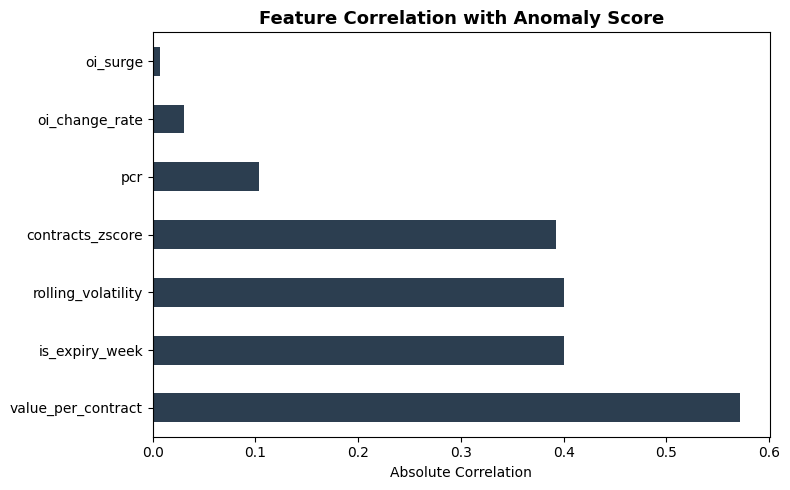


Saving results...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Done! Files downloaded.


In [7]:
# Cell 7 — Model Evaluation + Save Results

# ── Agreement Analysis ────────────────────────────────────
print("── Model Agreement Analysis ──")
all_agree_anomaly = ((if_preds == 1) & (lstm_preds == 1) & (dbscan_preds == 1)).sum()
two_agree = ((if_preds + lstm_preds + dbscan_preds) == 2).sum()
only_one = ((if_preds + lstm_preds + dbscan_preds) == 1).sum()

print(f"All 3 models agree (anomaly): {all_agree_anomaly:,}")
print(f"Exactly 2 models agree:       {two_agree:,}")
print(f"Only 1 model flags:           {only_one:,}")

# ── Top Anomalous Events ──────────────────────────────────
print("\n── Top 10 Most Anomalous Trading Days (NIFTY) ──")
nifty_anomalies = options[
    (options["SYMBOL"] == "NIFTY") &
    (options["ensemble_anomaly"] == 1)
].groupby("TIMESTAMP").agg(
    anomaly_count=("ensemble_anomaly", "sum"),
    avg_pcr=("pcr", "mean"),
    avg_oi_surge=("oi_surge", "mean"),
    total_contracts=("CONTRACTS", "sum")
).sort_values("anomaly_count", ascending=False).head(10)

print(nifty_anomalies.to_string())

# ── Feature Importance (via IF scores) ───────────────────
print("\n── Feature Importance ──")
feature_importance = pd.Series(
    np.abs(options[feature_cols].corrwith(pd.Series(ensemble_score))),
    index=feature_cols
).sort_values(ascending=False)
print(feature_importance)

# ── Final Summary Plot ────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
feature_importance.plot(kind='barh', ax=ax, color='#2c3e50')
ax.set_title("Feature Correlation with Anomaly Score", fontsize=13, fontweight='bold')
ax.set_xlabel("Absolute Correlation")
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=150, bbox_inches='tight')
plt.show()

# ── Save Results ──────────────────────────────────────────
print("\nSaving results...")
options.to_csv("fno_anomaly_results.csv", index=False)

# Download the results and plots
from google.colab import files
files.download("fno_anomaly_results.csv")
files.download("anomaly_detection_results.png")
files.download("feature_importance.png")
print("Done! Files downloaded.")